# Generate AF-3 Splits
Interfactive notebook to generate and save AlphaFold-3-style train/validation splits for training deep learning models.
We use a notebook over a script to facilitate documentation and error detection.

## Training Datasets

### Separate Train/Validation datasets by date cutoff

In [1]:
import pandas as pd

# NOTE: The dataframes must have token information, i.e., the column "n_total_tokens", which can be created using the scripts in `splits`
pn_units_df_path = "/projects/ml/RF2_allatom/datasets/pdb/2024_09_10/pn_units_df_with_token_counts.parquet"
interfaces_df_path = "/projects/ml/RF2_allatom/datasets/pdb/2024_09_10/interfaces_df_with_token_counts.parquet"

# (We must load all columns, since we will later save out the dataframes to different paths)
pn_units_df = pd.read_parquet(pn_units_df_path)
interfaces_df = pd.read_parquet(interfaces_df_path)

> "Any polymer chain containing fewer than 4 resolved residues is filtered out"

In [2]:
from cifutils.enums import ChainType

# Remove polymer chains with fewer than 4 resolved residues
print(f"Number of PN Units prior to removing polymer chains with fewer than 4 resolved residues: {len(pn_units_df)}")
pn_units_df = pn_units_df[
    (pn_units_df["q_pn_unit_num_resolved_residues"] > 3) | (pn_units_df["q_pn_unit_type"] == ChainType.NON_POLYMER)
]
print(f"Number of PN Units after removing polymer chains with fewer than 4 resolved residues: {len(pn_units_df)}")

# ...and same thing from the interfaces DF
print(
    f"Number of Interfaces prior to removing polymer chains with fewer than 4 resolved residues: {len(interfaces_df)}"
)
interfaces_df = interfaces_df[
    (interfaces_df["pn_unit_1_num_resolved_residues"] > 3) | (interfaces_df["pn_unit_1_type"] == ChainType.NON_POLYMER)
]
interfaces_df = interfaces_df[
    (interfaces_df["pn_unit_2_num_resolved_residues"] > 3) | (interfaces_df["pn_unit_2_type"] == ChainType.NON_POLYMER)
]
print(f"Number of Interfaces after removing polymer chains with fewer than 4 resolved residues: {len(interfaces_df)}")

Number of PN Units prior to removing polymer chains with fewer than 4 resolved residues: 3482512
Number of PN Units after removing polymer chains with fewer than 4 resolved residues: 3476270
Number of Interfaces prior to removing polymer chains with fewer than 4 resolved residues: 6221385
Number of Interfaces after removing polymer chains with fewer than 4 resolved residues: 6205471


> "The structure must have been released to the PDB before the cutoff date of 2021-09-30" - AF3 Supplement, p. 5

In [3]:
from pathlib import Path

# ...define the training date cutoff
# (This is the "release date", not the "deposition date", which can differ by up to a year)
# From AF-3: "The structure must have been released to the PDB before the cutoff date of 2021-09-30"
TRAIN_DATE_CUTOFF = pd.to_datetime("2021-09-30")
OUT_DIR = "/projects/ml/RF2_allatom/datasets/af3_splits/2024_09_23"

# ...create the output directory, if it does not exist
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ...get the PDB IDs of the proteins that were released before the cutoff
pdbs_before_cutoff = pn_units_df[pn_units_df["release_date"] < TRAIN_DATE_CUTOFF]["pdb_id"].unique()

# ...subselect the pn_units_df and interfaces_df to only include the proteins released before the cutoff
pn_units_df_train = pn_units_df[pn_units_df["pdb_id"].isin(pdbs_before_cutoff)]
interfaces_df_train = interfaces_df[interfaces_df["pdb_id"].isin(pdbs_before_cutoff)]
print(f"Training data: {len(pn_units_df_train):,} proteins, {len(interfaces_df_train):,} interfaces")

pn_units_df_val = pn_units_df[~pn_units_df["pdb_id"].isin(pdbs_before_cutoff)]
interfaces_df_val = interfaces_df[~interfaces_df["pdb_id"].isin(pdbs_before_cutoff)]
print(f"Candidate validation data: {len(pn_units_df_val):,} proteins, {len(interfaces_df_val):,} interfaces")

# ...remove rows without cluster information
pn_units_df_train = pn_units_df_train.dropna(subset=["cluster"])
interfaces_df_train = interfaces_df_train.dropna(subset=["cluster"])
print(
    f"Training data after removing proteins without cluster information: {len(pn_units_df_train):,} proteins, {len(interfaces_df_train):,} interfaces"
)

pn_units_df_val = pn_units_df_val.dropna(subset=["cluster"])
interfaces_df_val = interfaces_df_val.dropna(subset=["cluster"])
print(
    f"Candidate validation data after removing proteins without cluster information: {len(pn_units_df_val):,} proteins, {len(interfaces_df_val):,} interfaces"
)

Training data: 2,609,265 proteins, 4,505,714 interfaces
Candidate validation data: 867,005 proteins, 1,699,757 interfaces
Training data after removing proteins without cluster information: 2,563,749 proteins, 4,431,038 interfaces
Candidate validation data after removing proteins without cluster information: 858,711 proteins, 1,685,207 interfaces


Note that we leave the other filters (resolution, number of polymer chains) to be applied dynamically within the `PandasDataset` to enable greater flexibility downstream.

In [4]:
# ...save out the training dataframes to disk
pn_units_df_train.to_parquet(f"{OUT_DIR}/pn_units_df_train.parquet")
interfaces_df_train.to_parquet(f"{OUT_DIR}/interfaces_df_train.parquet")

# ...save out the candidate validation dataframes to disk
# (The "candidate" validation dataframes are all examples that were not included in the training dataframes and are thus candidates for validation)
pn_units_df_val.to_parquet(f"{OUT_DIR}/pn_units_df_candidate_val.parquet")
interfaces_df_val.to_parquet(f"{OUT_DIR}/interfaces_df_candidate_val.parquet")

/home/ncorley/.conda/envs/datahub/lib/python3.10/site-packages/seaborn/distributions.py:474: RuntimeWarning: invalid value encountered in subtract
  edges = res[orient].to_numpy() - widths / 2


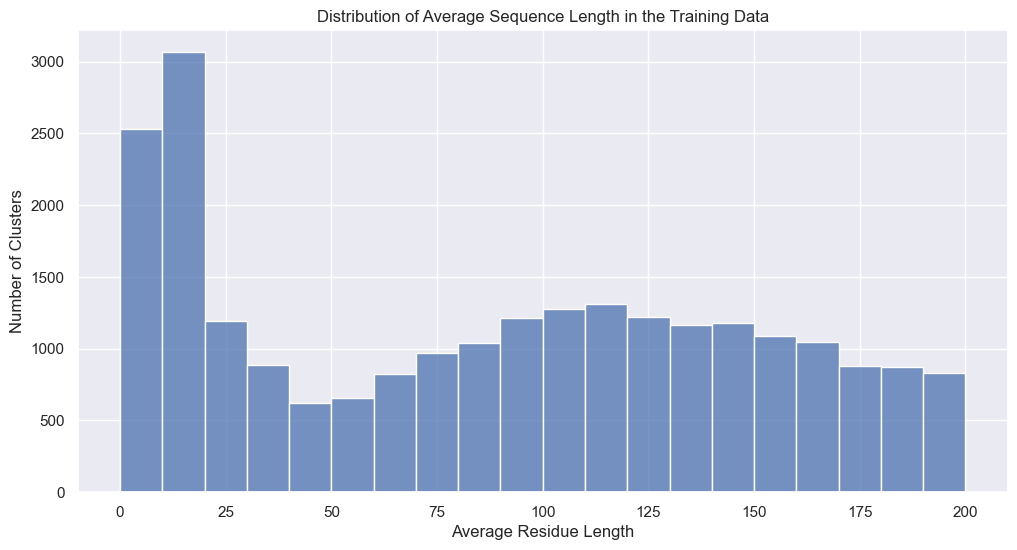

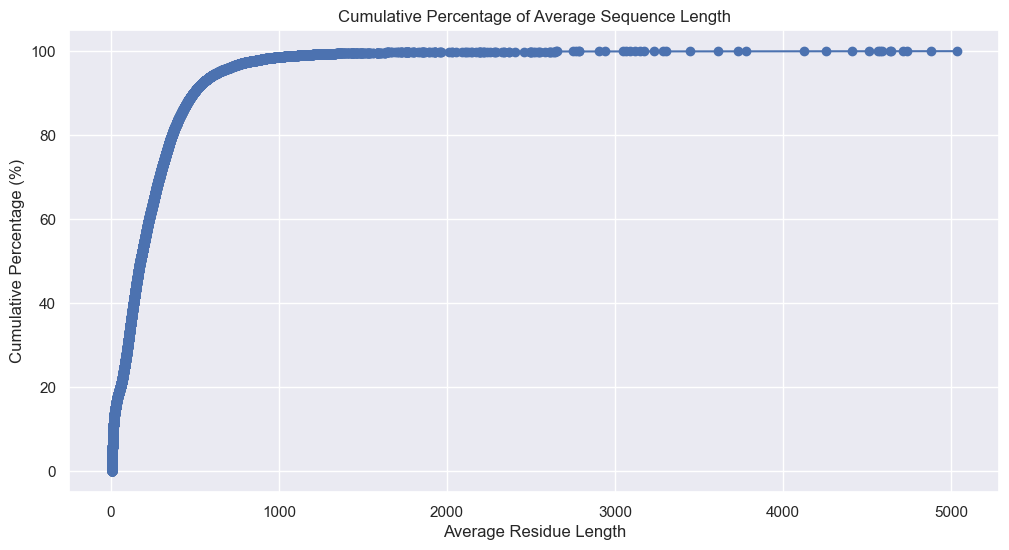

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# For each protein cluster, calculate the average residue length
protein_pn_units = pn_units_df_train[pn_units_df_train["q_pn_unit_type"] == ChainType.POLYPEPTIDE_L]
cluster_avg_residue_length = protein_pn_units.groupby("cluster")["q_pn_unit_sequence_length"].mean()

# Define custom bin edges for the histogram
bins = list(range(0, 201, 10)) + [float("inf")]

# Plot histogram with bins of 10 residues
sns.set_theme()
plt.figure(figsize=(12, 6))
sns.histplot(cluster_avg_residue_length, bins=bins)
plt.title("Distribution of Average Sequence Length in the Training Data")
plt.xlabel("Average Residue Length")
plt.ylabel("Number of Clusters")
plt.ylim(0, None)  # Start y-axis from 0
plt.show()

# Create cumulative percentage plot
sorted_lengths = np.sort(cluster_avg_residue_length)
cumulative_percentage = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100

plt.figure(figsize=(12, 6))
plt.plot(sorted_lengths, cumulative_percentage, marker="o")
plt.title("Cumulative Percentage of Average Sequence Length")
plt.xlabel("Average Residue Length")
plt.ylabel("Cumulative Percentage (%)")
plt.grid(True)
plt.show()

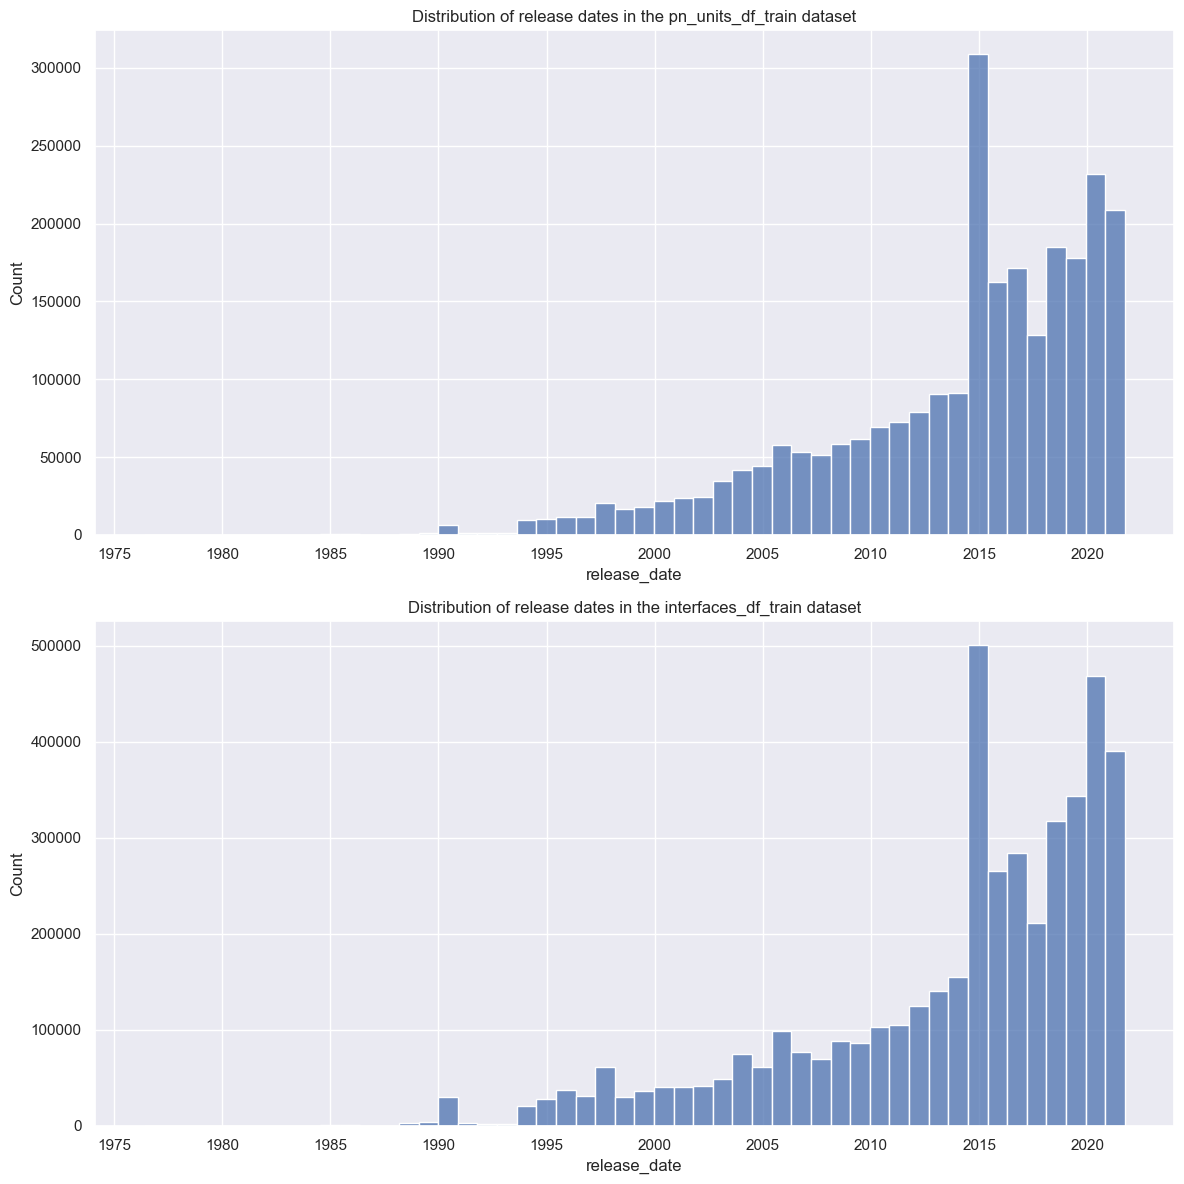

In [9]:
# ...visualize the distribution of release dates in the training data
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
sns.histplot(pn_units_df_train["release_date"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of release dates in the pn_units_df_train dataset")

# Plot the distribution of release dates in the interfaces_df_train dataset
sns.histplot(interfaces_df_train["release_date"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of release dates in the interfaces_df_train dataset")

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

Now, we're done with the training datasets! Onto validation.

## Validation Datasets: Interfaces

### Step 1: Filter the validation dataset based on basic entry-level criteria

> "Take all targets released after 2021-09-30 and before 2023-01-13 and remove targets with total number of tokens greater than 2560, more than one thousand chains, or resolution greater than 4.5" - AF3 Supplement, p. 31

In [5]:
MIN_VAL_DATE = pd.to_datetime("2021-09-30")
MAX_VAL_DATE = pd.to_datetime("2023-01-13")
TOKEN_LIMIT = 550  # AlphaFold3 uses 2,560 tokens (later filtered down to 2048), but with our current engineering, we can only handle 550 tokens
RESOLUTION_LIMIT = 4.5
CHAIN_LIMIT = 1000

print(f"Number of rows prior to filtering: {len(interfaces_df_val):,}")

# ...filter to only include rows within the interfaces dataframe that are within the validation date range
candidate_interfaces_df_val = interfaces_df_val[
    (interfaces_df_val["release_date"] > MIN_VAL_DATE) & (interfaces_df_val["release_date"] < MAX_VAL_DATE)
]
print(f"Number of rows within validation date range: {len(candidate_interfaces_df_val ):,}")

# ...assert that there are no rows with a release date outside of the validation date range
assert candidate_interfaces_df_val["release_date"].min() > MIN_VAL_DATE
assert candidate_interfaces_df_val["release_date"].max() < MAX_VAL_DATE

# ...filter again to only include rows with fewer tokens than TOKEN_LIMIT
candidate_interfaces_df_val = candidate_interfaces_df_val[candidate_interfaces_df_val["n_tokens_total"] < TOKEN_LIMIT]
print(f"Number of rows within validation date range and token limit: {len(candidate_interfaces_df_val ):,}")

# ...assert that there are no rows with more tokens than the token limit
assert candidate_interfaces_df_val["n_tokens_total"].max() < TOKEN_LIMIT

# ...filter once more to only include rows with a resolution less than RESOLUTION_LIMIT
candidate_interfaces_df_val = candidate_interfaces_df_val[candidate_interfaces_df_val["resolution"] < RESOLUTION_LIMIT]
print(
    f"Number of rows within validation date range, token limit, and resolution limit: {len(candidate_interfaces_df_val):,}"
)
assert candidate_interfaces_df_val["resolution"].max() < RESOLUTION_LIMIT

# ...filter to examples with fewer than CHAIN_LIMIT chains
candidate_interfaces_df_val = candidate_interfaces_df_val[
    candidate_interfaces_df_val["num_polymer_pn_units"] < CHAIN_LIMIT
]
print(
    f"Number of rows within validation date range, token limit, resolution limit, and chain limit: {len(candidate_interfaces_df_val):,}"
)
assert candidate_interfaces_df_val["num_polymer_pn_units"].max() < CHAIN_LIMIT

Number of rows prior to filtering: 1,685,207
Number of rows within validation date range: 705,320
Number of rows within validation date range and token limit: 41,274
Number of rows within validation date range, token limit, and resolution limit: 40,009
Number of rows within validation date range, token limit, resolution limit, and chain limit: 40,009


Text(0.5, 1.0, 'Distribution of release dates in the deduplicated_interfaces_df_val dataset')

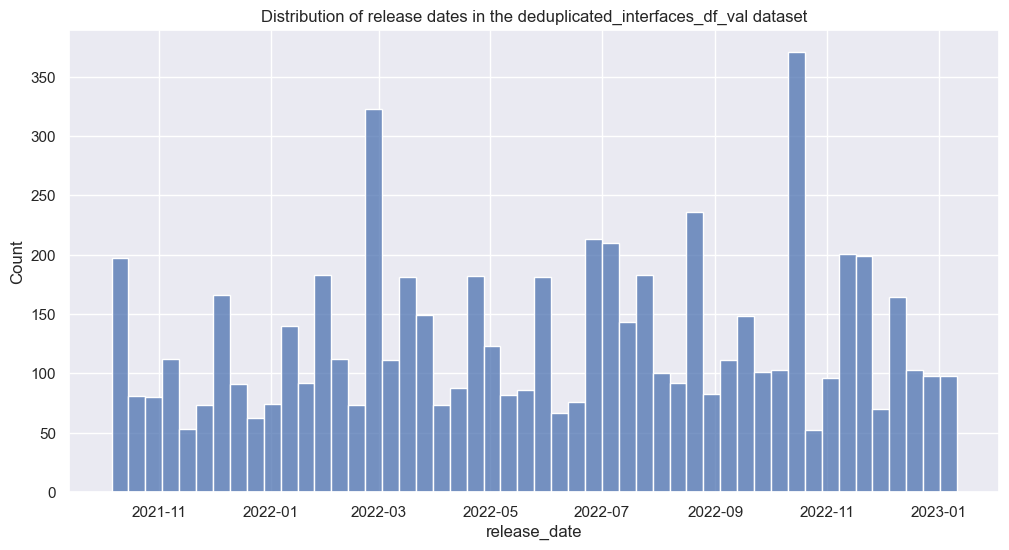

In [6]:
# Create a plot of candidate interfaces by release date
import matplotlib.pyplot as plt
import seaborn

# ...create a new dataframe that is deduplicated by "pdb_id" (for visualization purposes)
deduplicated_interfaces_df_val = candidate_interfaces_df_val.drop_duplicates(subset="pdb_id")

# Plot the distribution of release dates in the deduplicated_interfaces_df_val dataset
seaborn.set_theme()
fig, ax = plt.subplots(figsize=(12, 6))
seaborn.histplot(deduplicated_interfaces_df_val["release_date"], bins=50, ax=ax)

# Set the title and labels
ax.set_title("Distribution of release dates in the deduplicated_interfaces_df_val dataset")

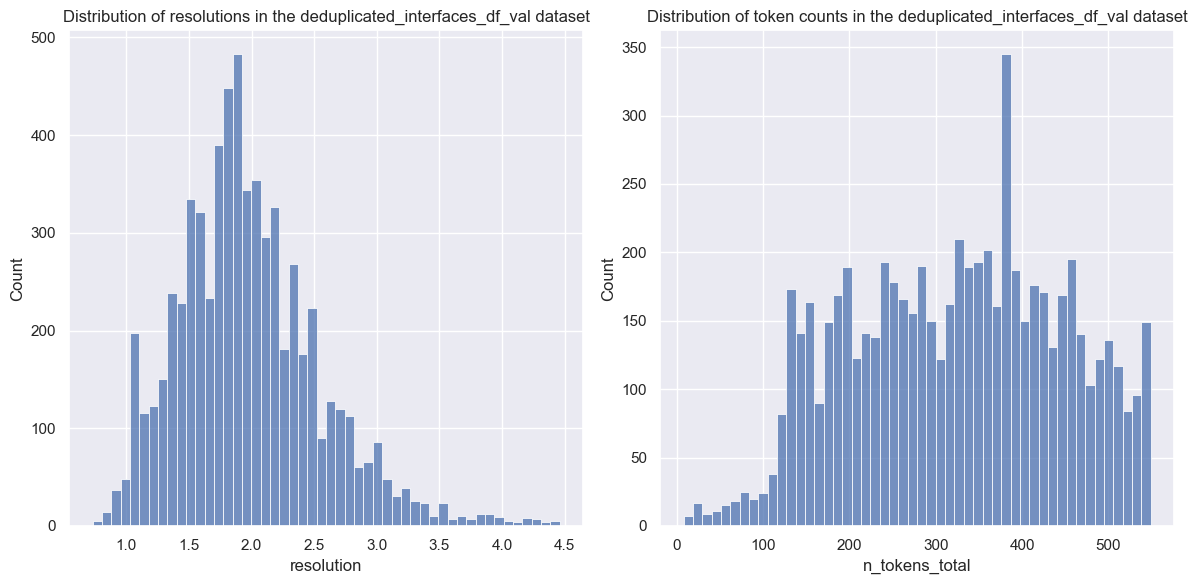

In [10]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the distribution of resolutions in the deduplicated_interfaces_df_val dataset
sns.histplot(deduplicated_interfaces_df_val["resolution"], bins=50, ax=axes[0])

# Plot the distribution of token counts in the deduplicated_interfaces_df_val dataset
axes[0].set_title("Distribution of resolutions in the deduplicated_interfaces_df_val dataset")
sns.histplot(deduplicated_interfaces_df_val["n_tokens_total"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of token counts in the deduplicated_interfaces_df_val dataset")
plt.tight_layout()

plt.show()

### Step 2: Filter to low-homology interfaces

> Filter to only low homology interfaces, which are defined as those where no target in the training set contains
two chains with high homology to the chains involved in the interface, where high homology here means >
40% sequence identity for polymers or > 0.85 tanimoto similarity for ligands. Additionally filter out interfaces
involving a ligand with ranking model fit less than 0.5 or with multiple residues - AF3 Supplement, p. 31

Accomplishing this task of filtering to low-homology interfaces is somewhat trickier. Our output to this step will be the `interfaces_df`, only containing rows that:
- Contain one `pn_unit` which we determine is *dissimilar* from all `pn_units` within the train set of its respective type (same 40% sequence identity cluster for proteins, 0.85 tanimoto similarity for ligands)
- Do not involve a ligand with ranking model fit less than 0.5
- Do not involve a ligand with multiple residues

This criteria may be stricter than AF-3's definition of "low homology", since they exclude only interfaces with a single target in the training set contains two chains with high homology to the chains involved in the interface.

First, we filter out interfaces involving a ligand with multiple residues or multiple chains, since they're nasty to work with...

In [11]:
from cifutils.enums import ChainType

# ...remove examples where `pn_unit_1` is a non-polymer but is multi-residue or multi-chain
candidate_interfaces_df_val = candidate_interfaces_df_val[
    ~(
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (
            candidate_interfaces_df_val["pn_unit_1_is_multiresidue"]
            | candidate_interfaces_df_val["pn_unit_1_is_multichain"]
        )
    )
]

# ...and the same for `pn_unit_2`
print(
    f"Number of rows in the candidate_interfaces_df_val dataset prior to filtering out non-polymer multi-residue chains: {len(candidate_interfaces_df_val):,}"
)
candidate_interfaces_df_val = candidate_interfaces_df_val[
    ~(
        (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
        & (
            candidate_interfaces_df_val["pn_unit_2_is_multiresidue"]
            | candidate_interfaces_df_val["pn_unit_2_is_multichain"]
        )
    )
]
print(
    f"Number of rows in the candidate_interfaces_df_val dataset after filtering out non-polymer multi-residue chains: {len(candidate_interfaces_df_val):,}"
)

Number of rows in the candidate_interfaces_df_val dataset prior to filtering out non-polymer multi-residue chains: 39,946
Number of rows in the candidate_interfaces_df_val dataset after filtering out non-polymer multi-residue chains: 39,492


We must also throw out interfaces that involve a ligand with ranking model fit less than 0.5 (which is, by definition, half of the ligands annotated with fit-to-density). We only have fit-to-density in the PN Units DF, so must work with that dataframe for the moment.

In [12]:
import numpy as np

FIT_TO_DENSITY_CUTOFF = 0.5

# ...subset to only non-polymers
candidate_pn_units_df_non_polymers = pn_units_df_val[pn_units_df_val["q_pn_unit_type"] == ChainType.NON_POLYMER.value]

# ...record the PDB IDs and pn_unit IIDs that fail the criteria
ligands_that_fail_criteria = set()
num_with_no_ligand_validity = 0
num_below_cutoff = 0
num_above_cutoff = 0

# ...loop through the non-polymers and note the pn_units that do NOT meet the criteria (we will later remove them from the interfaces and pn_units dataframes)
for row in candidate_pn_units_df_non_polymers.itertuples():
    # ...eval the "q_pn_unit_ligand_validity" column
    try:
        ligand_validity = eval(row.q_pn_unit_ligand_validity, {"nan": np.nan})
    except Exception as e:
        print(f"Error evaluating ligand validity for {row.pdb_id} {row.q_pn_unit_chain_id}: {e}")
        ligand_validity = None

    ranking_model_fit = (
        # Heinous expression to evaluate the the string representation and extract the ranking model fit (there should only be one ligand represented, since we already removed multi-residue ligands))
        list(eval(row.q_pn_unit_ligand_validity, {"nan": np.nan})["ranking_model_fit"].values())[0]
        if ligand_validity
        and "ranking_model_fit" in ligand_validity
        and ligand_validity["ranking_model_fit"]
        and len(ligand_validity["ranking_model_fit"]) == 1
        else None
    )

    # ...if the ranking model fit is not present, or is below the cutoff, add the PDB ID and the pn_unit IID to the set to of examples to remove
    if not ranking_model_fit:
        num_with_no_ligand_validity += 1
        ligands_that_fail_criteria.add(tuple([row.pdb_id, row.q_pn_unit_iid]))
    elif ranking_model_fit < FIT_TO_DENSITY_CUTOFF:
        num_below_cutoff += 1
        ligands_that_fail_criteria.add(tuple([row.pdb_id, row.q_pn_unit_iid]))
    else:
        num_above_cutoff += 1

print(f"Number of rows with no or null ranking model fit: {num_with_no_ligand_validity:,}")
print(f"Number of rows with ranking model fit below cutoff: {num_below_cutoff:,}")
print(f"Number of rows with ranking model fit above cutoff: {num_above_cutoff:,}")

Number of rows with no or null ranking model fit: 272,931
Number of rows with ranking model fit below cutoff: 119,139
Number of rows with ranking model fit above cutoff: 133,673


In [13]:
# ...log the number of ligand interfaces prior to filtering
interfaces_involving_ligand_before = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
    | (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
]
print(
    f"Number of interfaces involving a ligand prior to filtering out ligands with low fit-to-density: {len(interfaces_involving_ligand_before ):,}"
)

# Remove the ligands that do not meet the fit-to-density criteria from the candidate_interfaces_df_val
interfaces_to_keep = candidate_interfaces_df_val.apply(
    lambda row: (row["pdb_id"], row["pn_unit_1_iid"]) not in ligands_that_fail_criteria, axis=1
)
interfaces_to_keep &= candidate_interfaces_df_val.apply(
    lambda row: (row["pdb_id"], row["pn_unit_2_iid"]) not in ligands_that_fail_criteria, axis=1
)

candidate_interfaces_df_val = candidate_interfaces_df_val[interfaces_to_keep]
interfaces_involving_ligand_after = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
    | (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
]

# ...log the number of ligand interfaces after filtering
# (Typically, we would expect to move ~30% of ligand interfaces, since newer ligands tend to have better fit-to-density)
print(
    f"Number of interfaces involving a ligand after filtering out ligands with low fit-to-density: {len(interfaces_involving_ligand_after):,}"
)
print(f"Number of rows remaining in the candidate_interfaces_df_val dataset: {len(candidate_interfaces_df_val):,}")

Number of interfaces involving a ligand prior to filtering out ligands with low fit-to-density: 30,157
Number of interfaces involving a ligand after filtering out ligands with low fit-to-density: 20,090
Number of rows remaining in the candidate_interfaces_df_val dataset: 29,425


And finally we filter out low-homology interfaces. To review, we define low-homology as containing one `pn_unit` which we consider *dissimilar* from all `pn_units` within the train site of its respective type (same 40% sequence identity cluster for proteins, 0.85 tanimoto similarity for ligands)

In [14]:
import pickle

# Remove non-polymer rows where a ligand name is not in our similarity to train set map (i.e., the ligand was not sanitized by RDKit)
# ...load the tanimoto similarity to any ligand in the training set lookup dictionary (NOTE: This dictionary can be created using the `build_residue_by_residue_tanimoto_similarity_map.py` script in the `clustering` scripts directory)
RESIDUE_TO_MAX_SIMILARITY_WITH_TRAIN_SET_PATH = (
    "/projects/ml/RF2_allatom/datasets/af3_splits/2024_09_23/tanimoto_similarity_with_train_set.pkl"
)
with open(RESIDUE_TO_MAX_SIMILARITY_WITH_TRAIN_SET_PATH, "rb") as f:
    residue_to_max_similarity_to_train_set = pickle.load(f)

# ...get the ligand names that are in the lookup dictionary
ligand_names_in_lookup_dict = set(residue_to_max_similarity_to_train_set.keys())

# ...filter the candidate_interfaces_df_val to only include rows where both ligand names are in the lookup dictionary (or where the chain type is not a non-polymer)
# (Some ligands may not have been successfuly sanitized by RDKit, and we should remove these from the dataset)
print(
    f"Number of rows in the candidate_interfaces_df_val dataset before filtering out ligands not in the lookup map: {len(candidate_interfaces_df_val ):,}"
)
candidate_interfaces_df_val = candidate_interfaces_df_val[
    (
        candidate_interfaces_df_val["pn_unit_1_non_polymer_res_names"].isin(ligand_names_in_lookup_dict)
        | (candidate_interfaces_df_val["pn_unit_1_type"] != ChainType.NON_POLYMER.value)
    )
    & (
        candidate_interfaces_df_val["pn_unit_2_non_polymer_res_names"].isin(ligand_names_in_lookup_dict)
        | (candidate_interfaces_df_val["pn_unit_2_type"] != ChainType.NON_POLYMER.value)
    )
]
# (This filter should not remove very many rows (~1% maximum); if it does, it may indicate that the residue names were not sanitized correctly)
print(
    f"Number of rows in the candidate_interfaces_df_val dataset after filtering out ligands not in the lookup map: {len(candidate_interfaces_df_val ):,}"
)

Number of rows in the candidate_interfaces_df_val dataset before filtering out ligands not in the lookup map: 29,425
Number of rows in the candidate_interfaces_df_val dataset after filtering out ligands not in the lookup map: 29,390


In [15]:
TANIMOTO_SIMILARITY_CUTOFF = 0.85

# ...add columns to candidate_interfaces_df_val that indicate whether the pn_units are novel (i.e., not in the training set)
candidate_interfaces_df_val["pn_unit_1_is_novel"] = False
candidate_interfaces_df_val["pn_unit_2_is_novel"] = False

# ...get all of the clusters in the training set, which are clustered by 40% sequence identity for proteins, 100% sequence identity for nucelic acids, 100% sequence identity for small peptides, and CCD identity for ligands
clusters_in_train_set = set(pn_units_df_train["cluster"].unique())

# ...iterate through all interfaces
# We keep the interface IF AND ONLY IF one of the two pn_units involved in the interface is low-homology to the training set
interfaces_to_remove = set()
for row in candidate_interfaces_df_val.itertuples():
    match row.pn_unit_1_type:
        case ChainType.NON_POLYMER.value:
            # ...check if the non-polymer is similar to any non-polymers in the training set (excluding the ligand in the case of a fallback)
            pn_unit_1_is_novel = (
                residue_to_max_similarity_to_train_set.get(row.pn_unit_1_non_polymer_res_names, 1)
                < TANIMOTO_SIMILARITY_CUTOFF
            )
        case _:
            # ...check if the polymer is similar to any polymer in the training set (i.e., based on 40% sequence identity cluster for proteins, 100% for nucleic acids, 100% for small peptides)
            pn_unit_1_is_novel = row.pn_unit_1_cluster not in clusters_in_train_set

    match row.pn_unit_2_type:
        case ChainType.NON_POLYMER.value:
            # ...check if the non-polymer is similar to any non-polymers in the training set (excluding the ligand in the case of a fallback)
            pn_unit_2_is_novel = (
                residue_to_max_similarity_to_train_set.get(row.pn_unit_2_non_polymer_res_names, 1)
                < TANIMOTO_SIMILARITY_CUTOFF
            )
        case _:
            # ...check if the polymer is similar to any polymer in the training set (i.e., based on 40% sequence identity cluster for proteins)
            pn_unit_2_is_novel = row.pn_unit_2_cluster not in clusters_in_train_set

    if pn_unit_1_is_novel or pn_unit_2_is_novel:
        # Keep if either pn_unit is novel
        candidate_interfaces_df_val.at[row.Index, "pn_unit_1_is_novel"] = pn_unit_1_is_novel
        candidate_interfaces_df_val.at[row.Index, "pn_unit_2_is_novel"] = pn_unit_2_is_novel
        continue
    else:
        # Otherwise, add the interface to the set of interfaces to remove, since both pn_units are homologous to the training set
        interfaces_to_remove.add(row.Index)

print(f"Number of interfaces: {len(candidate_interfaces_df_val):,}")
print(f"Number of interfaces to remove: {len(interfaces_to_remove):,}")

# Remove the interfaces that do not meet the criteria
candidate_interfaces_df_val = candidate_interfaces_df_val.drop(interfaces_to_remove)
print(f"Number of interfaces remaining: {len(candidate_interfaces_df_val):,}")

Number of interfaces: 29,390
Number of interfaces to remove: 18,696
Number of interfaces remaining: 10,694


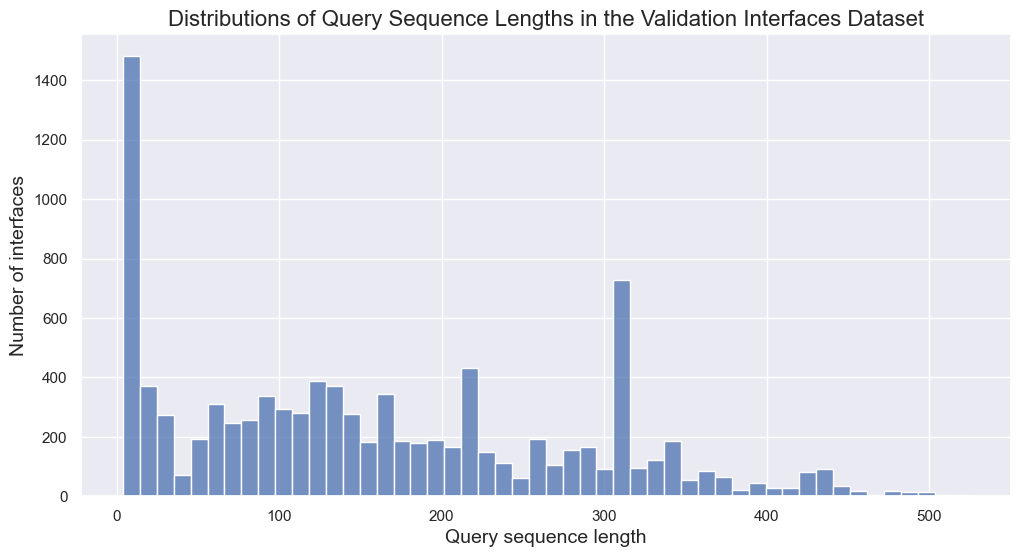

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming candidate_interfaces_df_val and ChainType are defined elsewhere in your code

# Filter the data for the two types of polypeptides
protein_pn_unit_1 = candidate_interfaces_df_val[
    candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L
]
protein_pn_unit_2 = candidate_interfaces_df_val[
    candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L
]

# Sum the two distributions
combined_lengths = pd.concat([
    protein_pn_unit_1["pn_unit_1_num_resolved_residues"],
    protein_pn_unit_2["pn_unit_2_num_resolved_residues"]
])

# Plot the combined distribution
plt.figure(figsize=(12, 6))
sns.histplot(combined_lengths, bins=50)
plt.title("Distributions of Query Sequence Lengths in the Validation Interfaces Dataset", fontsize=16)
plt.xlabel("Query sequence length", fontsize=14)
plt.ylabel("Number of interfaces", fontsize=14)
# Remove log scale from y-axis
plt.yscale("linear")
plt.show()


### Step 3: Sample the interface validation set

Hurrah, we have out interfaces validation set! Now, we just need to sample:

> Take the following interface types only, possibly reducing number of clusters by sampling a subset of clusters
(number of samples given in brackets if reduced): protein-protein (600), protein-DNA (100), DNA-DNA (100),
Protein-ligand (600), DNA-ligand (50), ligand-ligand (200), protein-RNA, RNA-RNA, DNA-RNA, RNA-ligand.

In [16]:
# Define a dictionary to hold our final splits
interface_validation_splits = {
    "protein-protein": [],
    "protein-DNA": [],
    "DNA-DNA": [],
    "protein-ligand": [],
    "DNA-ligand": [],
    "ligand-ligand": [],
    "protein-RNA": [],
    "RNA-RNA": [],
    "DNA-RNA": [],
    "RNA-ligand": [],
    "peptide-X": [],
}

In [17]:
import random
import numpy as np
from datahub.preprocessing.constants import PEPTIDE_MAX_RESIDUES

# Set deterministic seeds
random.seed(42)
np.random.seed(42)

# Number of interfaces to sample for each split
NUM_PROTEIN_PROTEIN_CLUSTERS_TO_SAMPLE = 400  # AF-3 used 600, but since we exclude peptides, we will use 400
NUM_PROTEIN_DNA_CLUSTERS_TO_SAMPLE = 100
NUM_DNA_DNA_CLUSTERS_TO_SAMPLE = 100
NUM_PROTEIN_LIGAND_CLUSTERS_TO_SAMPLE = 600
NUM_DNA_LIGAND_CLUSTERS_TO_SAMPLE = 50
NUM_LIGAND_LIGAND_CLUSTERS_TO_SAMPLE = 200
NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE = (
    100  # AF-3 doesn't specify how many protein-RNA clusters to sample; we will take up to 100 (but probably fewer)
)
NUM_RNA_RNA_CLUSTERS_TO_SAMPLE = (
    150  # AF-3 doesn't specify how many RNA-RNA clusters to sample; we will take up to 150 (but probably fewer)
)
NUM_DNA_RNA_CLUSTERS_TO_SAMPLE = (
    100  # AF-3 doesn't specify how many DNA-RNA clusters to sample; we will take up to 100 (but probably fewer)
)
NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE = (
    100  # AF-3 doesn't specify how many RNA-ligand clusters to sample; we will take up to 100 (but probably fewer)
)
NUM_PEPTIDE_X_CLUSTERS_TO_SAMPLE = 200  # Not present in AF-3

In [18]:
# Protein-protein
protein_protein_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
    & (candidate_interfaces_df_val["pn_unit_1_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    & (candidate_interfaces_df_val["pn_unit_2_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
]
print(f"Number of protein-protein interfaces: {len(protein_protein_interfaces):,}")
protein_protein_interface_clusters = protein_protein_interfaces["cluster"].unique()
print(f"Number of unique protein-protein clusters: {len(protein_protein_interface_clusters):,}")

# Sample NUM_PROTEIN_PROTEIN_CLUSTERS_TO_SAMPLE protein-protein interface clusters
selected_protein_protein_clusters = random.sample(
    list(protein_protein_interface_clusters), NUM_PROTEIN_PROTEIN_CLUSTERS_TO_SAMPLE
)

# Select one interface from each cluster
for cluster in selected_protein_protein_clusters:
    cluster_interfaces = protein_protein_interfaces[protein_protein_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["protein-protein"].append(selected_interface)

assert len(interface_validation_splits["protein-protein"]) == NUM_PROTEIN_PROTEIN_CLUSTERS_TO_SAMPLE

Number of protein-protein interfaces: 1,224
Number of unique protein-protein clusters: 421


In [19]:
# Protein-DNA
protein_dna_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_1_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    )
]
print(f"Number of protein-DNA interfaces: {len(protein_dna_interfaces):,}")

# Count the number of protein-DNA clusters
print(f"Number of unique protein-DNA clusters: {len(protein_dna_interfaces['cluster'].unique()):,}")

# Sample 100 protein-DNA interface clusters
selected_protein_dna_clusters = random.sample(
    list(protein_dna_interfaces["cluster"].unique()), NUM_PROTEIN_DNA_CLUSTERS_TO_SAMPLE
)
for cluster in selected_protein_dna_clusters:
    cluster_interfaces = protein_dna_interfaces[protein_dna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["protein-DNA"].append(selected_interface)

assert len(interface_validation_splits["protein-DNA"]) == NUM_PROTEIN_DNA_CLUSTERS_TO_SAMPLE

Number of protein-DNA interfaces: 608
Number of unique protein-DNA clusters: 249


In [20]:
# DNA-DNA
dna_dna_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
]
print(f"Number of DNA-DNA interfaces: {len(dna_dna_interfaces):,}")
print(f"Number of unique DNA-DNA clusters: {len(dna_dna_interfaces['cluster'].unique()):,}")

selected_dna_dna_clusters = random.sample(list(dna_dna_interfaces["cluster"].unique()), NUM_DNA_DNA_CLUSTERS_TO_SAMPLE)
dna_dna_validation_interfaces = []
for cluster in selected_dna_dna_clusters:
    cluster_interfaces = dna_dna_interfaces[dna_dna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["DNA-DNA"].append(selected_interface)

assert len(interface_validation_splits["DNA-DNA"]) == NUM_DNA_DNA_CLUSTERS_TO_SAMPLE

Number of DNA-DNA interfaces: 1,616
Number of unique DNA-DNA clusters: 204


In [21]:
# Protein-ligand
protein_ligand_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_1_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    )
]
print(f"Number of protein-ligand interfaces: {len(protein_ligand_interfaces):,}")
print(f"Number of unique protein-ligand clusters: {len(protein_ligand_interfaces['cluster'].unique()):,}")

# Sample 600 protein-ligand interface clusters
selected_protein_ligand_clusters = random.sample(
    list(protein_ligand_interfaces["cluster"].unique()), NUM_PROTEIN_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in selected_protein_ligand_clusters:
    cluster_interfaces = protein_ligand_interfaces[protein_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["protein-ligand"].append(selected_interface)

assert len(interface_validation_splits["protein-ligand"]) == NUM_PROTEIN_LIGAND_CLUSTERS_TO_SAMPLE

Number of protein-ligand interfaces: 4,100
Number of unique protein-ligand clusters: 1,765


In [22]:
# DNA-ligand
dna_ligand_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
    )
]
print(f"Number of DNA-ligand interfaces: {len(dna_ligand_interfaces):,}")
print(f"Number of unique DNA-ligand clusters: {len(dna_ligand_interfaces['cluster'].unique()):,}")

# We only have 23 DNA-ligand clusters, so we will sample 20 of them
selected_dna_ligand_clusters = random.sample(
    list(dna_ligand_interfaces["cluster"].unique()), NUM_DNA_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in selected_dna_ligand_clusters:
    cluster_interfaces = dna_ligand_interfaces[dna_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["DNA-ligand"].append(selected_interface)

assert len(interface_validation_splits["DNA-ligand"]) == NUM_DNA_LIGAND_CLUSTERS_TO_SAMPLE

Number of DNA-ligand interfaces: 764
Number of unique DNA-ligand clusters: 108


In [23]:
# Ligand-ligand
ligand_ligand_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
]
print(f"Number of ligand-ligand interfaces: {len(ligand_ligand_interfaces):,}")
print(f"Number of unique ligand-ligand clusters: {len(ligand_ligand_interfaces['cluster'].unique()):,}")

seleected_ligand_ligand_clusters = random.sample(
    list(ligand_ligand_interfaces["cluster"].unique()), NUM_LIGAND_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in seleected_ligand_ligand_clusters:
    cluster_interfaces = ligand_ligand_interfaces[ligand_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["ligand-ligand"].append(selected_interface)

assert len(interface_validation_splits["ligand-ligand"]) == NUM_LIGAND_LIGAND_CLUSTERS_TO_SAMPLE

Number of ligand-ligand interfaces: 434
Number of unique ligand-ligand clusters: 271


In [24]:
# Protein-RNA
protein_rna_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_1_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_2_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
    )
]

num_unique_protein_rna_clusters = len(protein_rna_interfaces["cluster"].unique())
print(f"Number of protein-RNA interfaces: {len(protein_rna_interfaces):,}")
print(f"Number of unique protein-RNA clusters: {num_unique_protein_rna_clusters:,}")

if num_unique_protein_rna_clusters < NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of protein-RNA interfaces ({num_unique_protein_rna_clusters}) is less than the number of clusters to sample ({NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE}). Sampling all protein-RNA interfaces."
    )
    NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE = num_unique_protein_rna_clusters

selected_protein_rna_clusters = random.sample(
    list(protein_rna_interfaces["cluster"].unique()), NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE
)
for cluster in selected_protein_rna_clusters:
    cluster_interfaces = protein_rna_interfaces[protein_rna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["protein-RNA"].append(selected_interface)

assert len(interface_validation_splits["protein-RNA"]) == NUM_PROTEIN_RNA_CLUSTERS_TO_SAMPLE

Number of protein-RNA interfaces: 89
Number of unique protein-RNA clusters: 37


In [25]:
# RNA-RNA
rna_rna_interfaces = candidate_interfaces_df_val[
    (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
    & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
]

num_unique_rna_rna_clusters = len(rna_rna_interfaces["cluster"].unique())
print(f"Number of RNA-RNA interfaces: {len(rna_rna_interfaces):,}")
print(f"Number of unique RNA-RNA clusters: {num_unique_rna_rna_clusters:,}")

if num_unique_rna_rna_clusters < NUM_RNA_RNA_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of RNA-RNA interfaces ({num_unique_rna_rna_clusters}) is less than the number of clusters to sample ({NUM_RNA_RNA_CLUSTERS_TO_SAMPLE}). Sampling all RNA-RNA interfaces."
    )
    NUM_RNA_RNA_CLUSTERS_TO_SAMPLE = num_unique_rna_rna_clusters

selected_rna_rna_clusters = random.sample(list(rna_rna_interfaces["cluster"].unique()), NUM_RNA_RNA_CLUSTERS_TO_SAMPLE)
for cluster in selected_rna_rna_clusters:
    cluster_interfaces = rna_rna_interfaces[rna_rna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["RNA-RNA"].append(selected_interface)

assert len(interface_validation_splits["RNA-RNA"]) == NUM_RNA_RNA_CLUSTERS_TO_SAMPLE

Number of RNA-RNA interfaces: 132
Number of unique RNA-RNA clusters: 22


In [26]:
# DNA-RNA
dna_rna_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.DNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.DNA.value)
    )
]

num_unique_dna_rna_clusters = len(dna_rna_interfaces["cluster"].unique())
print(f"Number of DNA-RNA interfaces: {len(dna_rna_interfaces):,}")
print(f"Number of unique DNA-RNA clusters: {num_unique_dna_rna_clusters}")

if num_unique_dna_rna_clusters < NUM_DNA_RNA_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of DNA-RNA interfaces ({num_unique_dna_rna_clusters}) is less than the number of clusters to sample ({NUM_DNA_RNA_CLUSTERS_TO_SAMPLE}). Sampling all DNA-RNA interfaces."
    )
    NUM_DNA_RNA_CLUSTERS_TO_SAMPLE = num_unique_dna_rna_clusters

selected_dna_rna_clusters = random.sample(list(dna_rna_interfaces["cluster"].unique()), NUM_DNA_RNA_CLUSTERS_TO_SAMPLE)
for cluster in selected_dna_rna_clusters:
    cluster_interfaces = dna_rna_interfaces[dna_rna_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["DNA-RNA"].append(selected_interface)

assert len(interface_validation_splits["DNA-RNA"]) == NUM_DNA_RNA_CLUSTERS_TO_SAMPLE

Number of DNA-RNA interfaces: 13
Number of unique DNA-RNA clusters: 6


In [27]:
# RNA-ligand
rna_ligand_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.RNA.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.NON_POLYMER.value)
    )
    | (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.NON_POLYMER.value)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.RNA.value)
    )
]

num_unique_rna_ligand_clusters = len(rna_ligand_interfaces["cluster"].unique())
print(f"Number of RNA-ligand interfaces: {len(rna_ligand_interfaces):,}")
print(f"Number of unique RNA-ligand clusters: {num_unique_rna_ligand_clusters }")

if num_unique_rna_ligand_clusters < NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of RNA-ligand interfaces ({num_unique_rna_ligand_clusters }) is less than the number of clusters to sample ({NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE}). Sampling all RNA-ligand interfaces."
    )
    NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE = num_unique_rna_ligand_clusters

selected_rna_ligand_clusters = random.sample(
    list(rna_ligand_interfaces["cluster"].unique()), NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE
)
for cluster in selected_rna_ligand_clusters:
    cluster_interfaces = rna_ligand_interfaces[rna_ligand_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["RNA-ligand"].append(selected_interface)

assert len(interface_validation_splits["RNA-ligand"]) == NUM_RNA_LIGAND_CLUSTERS_TO_SAMPLE

Number of RNA-ligand interfaces: 388
Number of unique RNA-ligand clusters: 49


In [28]:
# Peptide-X
from datahub.preprocessing.constants import SUPPORTED_CHAIN_TYPES

SUPPORTED_CHAIN_TYPES_INTS = [type.value for type in SUPPORTED_CHAIN_TYPES]

peptide_x_interfaces = candidate_interfaces_df_val[
    (
        (candidate_interfaces_df_val["pn_unit_1_type"] == ChainType.POLYPEPTIDE_L.value)
        & (candidate_interfaces_df_val["pn_unit_1_sequence_length"] < PEPTIDE_MAX_RESIDUES)
        & (np.isin(candidate_interfaces_df_val["pn_unit_2_type"], SUPPORTED_CHAIN_TYPES_INTS))
    )
    | (
        (candidate_interfaces_df_val["pn_unit_2_sequence_length"] < PEPTIDE_MAX_RESIDUES)
        & (candidate_interfaces_df_val["pn_unit_2_type"] == ChainType.POLYPEPTIDE_L.value)
        & (np.isin(candidate_interfaces_df_val["pn_unit_1_type"], SUPPORTED_CHAIN_TYPES_INTS))
    )
]

num_unique_peptide_x_clusters = len(peptide_x_interfaces["cluster"].unique())
print(f"Number of peptide-X interfaces: {len(peptide_x_interfaces):,}")
print(f"Number of unique peptide-X clusters: {num_unique_peptide_x_clusters}")

if num_unique_peptide_x_clusters < NUM_PEPTIDE_X_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of peptide-X interfaces ({num_unique_peptide_x_clusters}) is less than the number of clusters to sample ({NUM_PEPTIDE_X_CLUSTERS_TO_SAMPLE}). Sampling all peptide-X interfaces."
    )
    NUM_PEPTIDE_X_CLUSTERS_TO_SAMPLE = num_unique_peptide_x_clusters

selected_peptide_x_clusters = random.sample(
    list(peptide_x_interfaces["cluster"].unique()), NUM_PEPTIDE_X_CLUSTERS_TO_SAMPLE
)

for cluster in selected_peptide_x_clusters:
    cluster_interfaces = peptide_x_interfaces[peptide_x_interfaces["cluster"] == cluster]
    selected_interface = cluster_interfaces.sample(1)
    interface_validation_splits["peptide-X"].append(selected_interface)

assert len(interface_validation_splits["peptide-X"]) == NUM_PEPTIDE_X_CLUSTERS_TO_SAMPLE

Number of peptide-X interfaces: 1,306
Number of unique peptide-X clusters: 526


## Validation Data: Monomers

In [29]:
MIN_VAL_DATE = pd.to_datetime("2021-09-30")
MAX_VAL_DATE = pd.to_datetime("2023-01-13")
TOKEN_LIMIT = 550  # AlphaFold3 uses 2,560 tokens (later filtered down to 2048), but with our current engineering, we can only handle 550 tokens
RESOLUTION_LIMIT = 4.5
CHAIN_LIMIT = 1000

print(f"Number of rows prior to filtering: {len(pn_units_df_val):,}")

# ...filter to only inclues rows within the PN Units dataframe that are within the validation date range
candidate_pn_units_df_val = pn_units_df_val[
    (pn_units_df_val["release_date"] > MIN_VAL_DATE) & (pn_units_df_val["release_date"] < MAX_VAL_DATE)
]
print(f"Number of rows within validation date range: {len(candidate_pn_units_df_val ):,}")

# ...assert that there are no rows with a release date outside of the validation date range
assert candidate_pn_units_df_val["release_date"].min() > MIN_VAL_DATE
assert candidate_pn_units_df_val["release_date"].max() < MAX_VAL_DATE

# ...filter again to only include rows with fewer than 2,560 tokens
candidate_pn_units_df_val = candidate_pn_units_df_val[candidate_pn_units_df_val["n_tokens_total"] < TOKEN_LIMIT]
print(f"Number of rows within validation date range and token limit: {len(candidate_pn_units_df_val ):,}")

# ...assert that there are no rows with more than 2,560 tokens
assert candidate_pn_units_df_val["n_tokens_total"].max() < TOKEN_LIMIT

# ...filter once more to only include rows with a resolution greater than 4.5 angstrom
candidate_pn_units_df_val = candidate_pn_units_df_val[candidate_pn_units_df_val["resolution"] < RESOLUTION_LIMIT]
print(
    f"Number of rows within validation date range, token limit, and resolution limit: {len(candidate_pn_units_df_val ):,}"
)
assert candidate_pn_units_df_val["resolution"].max() < RESOLUTION_LIMIT

# ...filter to examples with fewer than 1,000 chains
candidate_pn_units_df_val = candidate_pn_units_df_val[candidate_pn_units_df_val["num_polymer_pn_units"] < CHAIN_LIMIT]
print(
    f"Number of rows within validation date range, token limit, resolution limit, and chain limit: {len(candidate_pn_units_df_val ):,}"
)
assert candidate_pn_units_df_val["num_polymer_pn_units"].max() < CHAIN_LIMIT

Number of rows prior to filtering: 858,711
Number of rows within validation date range: 352,884
Number of rows within validation date range and token limit: 41,351
Number of rows within validation date range, token limit, and resolution limit: 40,262
Number of rows within validation date range, token limit, resolution limit, and chain limit: 40,262


Filter to low-homology polymers (i.e., a cluster not seen during training)

In [30]:
# ...filter to polymers
polymer_chain_type_ints = [chain_type.value for chain_type in ChainType.get_polymers()]
candidate_pn_units_df_val_non_polymers = candidate_pn_units_df_val[
    candidate_pn_units_df_val["q_pn_unit_type"].isin(polymer_chain_type_ints)
]

print(
    f"Number of rows in the candidate_pn_units_df_val dataset before filtering out non-polymers: {len(candidate_pn_units_df_val):,}"
)
print(candidate_pn_units_df_val_non_polymers["q_pn_unit_type"].value_counts())
print(f"Number of rows after filtering out non-polymers: {len(candidate_pn_units_df_val_non_polymers):,}")

Number of rows in the candidate_pn_units_df_val dataset before filtering out non-polymers: 40,262
6    16551
3     1513
7      415
4       15
5        5
Name: q_pn_unit_type, dtype: int64
Number of rows after filtering out non-polymers: 18,499


In [31]:
# ...remove polymers that are similar to any polymers in the training set
clusters_in_training_set = set(pn_units_df_train["cluster"].unique())

# Use boolean indexing to filter out rows
candidate_pn_units_df_val_non_polymers = candidate_pn_units_df_val_non_polymers[
    ~candidate_pn_units_df_val_non_polymers["cluster"].isin(clusters_in_training_set)
]

print(
    f"Number of rows in the candidate_pn_units_df_val dataset after filtering out polymers that closely resemble training set examples: {len(candidate_pn_units_df_val_non_polymers):,}"
)

Number of rows in the candidate_pn_units_df_val dataset after filtering out polymers that closely resemble training set examples: 5,019


 From the AF-3 supplement:
 > 4. Sample 40 protein monomers and take all DNA and RNA monomers

In [32]:
monomer_validation_splits = {
    "protein": [],
    "DNA": [],
    "RNA": [],
    "peptide": [],  # Not present in AF-3
}

In [33]:
# Number of monomers to sample for each split
NUM_PROTEIN_MONOMER_CLUSTERS_TO_SAMPLE = 40
NUM_DNA_MONOMER_CLUSTERS_TO_SAMPLE = 100
NUM_RNA_MONOMER_CLUSTERS_TO_SAMPLE = 100
NUM_PEPTIDE_CLUSTERS_TO_SAMPLE = 40

# Set deterministic seeds
random.seed(42)
np.random.seed(42)

In [34]:
# Protein monomer
protein_monomers = candidate_pn_units_df_val_non_polymers[
    (candidate_pn_units_df_val_non_polymers["q_pn_unit_type"] == ChainType.POLYPEPTIDE_L.value)
    & (candidate_pn_units_df_val_non_polymers["q_pn_unit_sequence_length"] >= PEPTIDE_MAX_RESIDUES)
]
protein_monomer_clusters = protein_monomers["cluster"].unique()
print(f"Number of protein monomer clusters: {len(protein_monomers):,}")

# Sample NUM_PROTEIN_MONOMER_CLUSTERS_TO_SAMPLE protein monomer clusters
selected_protein_monomer_clusters = random.sample(
    list(protein_monomer_clusters), NUM_PROTEIN_MONOMER_CLUSTERS_TO_SAMPLE
)

# Select one monomer from each cluster
for cluster in selected_protein_monomer_clusters:
    cluster_monomers = protein_monomers[protein_monomers["cluster"] == cluster]
    selected_monomer = cluster_monomers.sample(1)
    monomer_validation_splits["protein"].append(selected_monomer)

assert len(monomer_validation_splits["protein"]) == NUM_PROTEIN_MONOMER_CLUSTERS_TO_SAMPLE

Number of protein monomer clusters: 3,091


In [35]:
# Peptide
peptide_monomers = candidate_pn_units_df_val_non_polymers[
    (candidate_pn_units_df_val_non_polymers["q_pn_unit_type"] == ChainType.POLYPEPTIDE_L.value)
    & (candidate_pn_units_df_val_non_polymers["q_pn_unit_sequence_length"] < PEPTIDE_MAX_RESIDUES)
]
peptide_monomer_clusters = peptide_monomers["cluster"].unique()
print(f"Number of peptide monomer clusters: {len(peptide_monomers):,}")

# Sample NUM_PEPTIDE_CLUSTERS_TO_SAMPLE peptide monomer clusters
selected_peptide_monomer_clusters = random.sample(list(peptide_monomer_clusters), NUM_PEPTIDE_CLUSTERS_TO_SAMPLE)

# Select one monomer from each cluster
for cluster in selected_peptide_monomer_clusters:
    cluster_monomers = peptide_monomers[peptide_monomers["cluster"] == cluster]
    selected_monomer = cluster_monomers.sample(1)
    monomer_validation_splits["peptide"].append(selected_monomer)

assert len(monomer_validation_splits["peptide"]) == NUM_PEPTIDE_CLUSTERS_TO_SAMPLE

Number of peptide monomer clusters: 779


In [36]:
# DNA monomer
dna_monomers = candidate_pn_units_df_val_non_polymers[
    candidate_pn_units_df_val_non_polymers["q_pn_unit_type"] == ChainType.DNA.value
]
dna_monomer_clusters = dna_monomers["cluster"].unique()
print(f"Number of DNA monomer clusters: {len(dna_monomers):,}")
if len(dna_monomer_clusters) < NUM_DNA_MONOMER_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of DNA monomer clusters ({len(dna_monomer_clusters)}) is less than the number of clusters to sample ({NUM_DNA_MONOMER_CLUSTERS_TO_SAMPLE}). Sampling all DNA monomer clusters."
    )
    NUM_DNA_MONOMER_CLUSTERS_TO_SAMPLE = len(dna_monomer_clusters)

selected_dna_monomer_clusters = random.sample(list(dna_monomer_clusters), NUM_DNA_MONOMER_CLUSTERS_TO_SAMPLE)
for cluster in selected_dna_monomer_clusters:
    cluster_monomers = dna_monomers[dna_monomers["cluster"] == cluster]
    selected_monomer = cluster_monomers.sample(1)
    monomer_validation_splits["DNA"].append(selected_monomer)

assert len(monomer_validation_splits["DNA"]) == NUM_DNA_MONOMER_CLUSTERS_TO_SAMPLE

Number of DNA monomer clusters: 799


In [37]:
# Take one example from each RNA cluster
rna_monomers = candidate_pn_units_df_val_non_polymers[
    candidate_pn_units_df_val_non_polymers["q_pn_unit_type"] == ChainType.RNA.value
]
rna_monomer_clusters = rna_monomers["cluster"].unique()
print(f"Number of RNA monomer clusters: {len(rna_monomers):,}")

if len(rna_monomer_clusters) < NUM_RNA_MONOMER_CLUSTERS_TO_SAMPLE:
    print(
        f"WARNING: The number of RNA monomer clusters ({len(rna_monomer_clusters)}) is less than the number of clusters to sample ({NUM_RNA_MONOMER_CLUSTERS_TO_SAMPLE}). Sampling all RNA monomer clusters."
    )
    NUM_RNA_MONOMER_CLUSTERS_TO_SAMPLE = len(rna_monomer_clusters)

selected_rna_monomer_clusters = random.sample(list(rna_monomer_clusters), NUM_RNA_MONOMER_CLUSTERS_TO_SAMPLE)
for cluster in selected_rna_monomer_clusters:
    cluster_monomers = rna_monomers[rna_monomers["cluster"] == cluster]
    selected_monomer = cluster_monomers.sample(1)
    monomer_validation_splits["RNA"].append(selected_monomer)

assert len(monomer_validation_splits["RNA"]) == NUM_RNA_MONOMER_CLUSTERS_TO_SAMPLE

Number of RNA monomer clusters: 338


## Save validation dataframes to disk

In [38]:
VALIDATION_OUTPUT_PATH = "/projects/ml/RF2_allatom/datasets/af3_splits/2024_09_23"

In [39]:
# ...concatenate each split into a single dataframe, adding a column "interface_type" which is set to the key of the dictionary that the interface belongs to
interface_validation_splits_df = pd.concat(
    [
        pd.concat(split).assign(interface_type=interface_type)
        for interface_type, split in interface_validation_splits.items()
    ]
)

print(f"Length of final_interface_validation_splits_df: {len(interface_validation_splits_df):,}")
print(
    f"Number of unique PDB IDs in final_interface_validation_splits_df: {interface_validation_splits_df['pdb_id'].nunique():,}"
)

Length of final_interface_validation_splits_df: 1,764
Number of unique PDB IDs in final_interface_validation_splits_df: 1,379


In [40]:
from cifutils.enums import ChainType


def get_validation_chain_type(chain_type: ChainType, num_residues: int) -> str:
    """
    Converts the chain type and number of residues to a validation chain type.

    The validation chain types are: protein, DNA, RNA, ligand, or peptide, where peptide is a protein with fewer than PEPTIDE_MAX_RESIDUES residues.
    """
    match chain_type:
        case ChainType.POLYPEPTIDE_L:
            if num_residues < PEPTIDE_MAX_RESIDUES:
                return "peptide"
            else:
                return "protein"
        case ChainType.DNA:
            return "DNA"
        case ChainType.RNA:
            return "RNA"
        case ChainType.NON_POLYMER:
            return "ligand"
        case _:
            raise ValueError(f"Invalid chain type: {chain_type}")


# Select the required columns
ENTRY_LEVEL_COLUMNS = ["pdb_id", "assembly_id", "resolution", "release_date", "method", "n_tokens_total"]
entry_level_val_df = interface_validation_splits_df[ENTRY_LEVEL_COLUMNS].copy()

# Create a column for interfaces_to_score
# Group by 'pdb_id' and 'assembly_id' and aggregate the required tuples
interfaces_to_score = (
    interface_validation_splits_df.groupby(["pdb_id", "assembly_id"])
    .apply(lambda group: [(row.pn_unit_1_iid, row.pn_unit_2_iid, row.interface_type) for row in group.itertuples()])
    .reset_index(name="interfaces_to_score")
)

# Merge the new column into the new_df
entry_level_val_df = pd.merge(entry_level_val_df, interfaces_to_score, on=["pdb_id", "assembly_id"])


# Create a column for pn_units_to_score
def get_pn_units_to_score(group):
    pn_units = set()
    for _, row in group.iterrows():
        if row["pn_unit_1_is_novel"]:
            pn_units.add(
                (
                    row["pn_unit_1_iid"],
                    get_validation_chain_type(ChainType(row["pn_unit_1_type"]), row["pn_unit_1_sequence_length"]),
                )
            )
        if row["pn_unit_2_is_novel"]:
            pn_units.add(
                (
                    row["pn_unit_2_iid"],
                    get_validation_chain_type(ChainType(row["pn_unit_2_type"]), row["pn_unit_2_sequence_length"]),
                )
            )
    return list(pn_units)


pn_units_to_score = (
    interface_validation_splits_df.groupby(["pdb_id", "assembly_id"])
    .apply(get_pn_units_to_score)
    .reset_index(name="pn_units_to_score")
)

# Merge the new column into the new_df
entry_level_val_df = pd.merge(entry_level_val_df, pn_units_to_score, on=["pdb_id", "assembly_id"])

# ...deduplicate the dataframe on 'pdb_id' and 'assembly_id'
print(f"Number of rows before deduplication: {len(entry_level_val_df):,}")
entry_level_val_df = entry_level_val_df.drop_duplicates(subset=["pdb_id", "assembly_id"])
print(f"Number of rows after deduplication: {len(entry_level_val_df):,}")

Number of rows before deduplication: 1,764
Number of rows after deduplication: 1,468


In [41]:
# ...same thing for monomers
monomer_validation_splits_df = pd.concat(
    [pd.concat(split).assign(polymer_type=polymer_type) for polymer_type, split in monomer_validation_splits.items()]
)

# ...create a new dataframe to hold the entry-level rows
new_rows = []

# ...iterate over each row in the monomer_validation_splits_df
for row in monomer_validation_splits_df.itertuples():
    pdb_id = row.pdb_id
    assembly_id = row.assembly_id
    pn_unit_to_add = (
        row.q_pn_unit_iid,
        get_validation_chain_type(ChainType(row.q_pn_unit_type), row.q_pn_unit_sequence_length),
    )

    # Check if the entry already exists in the entry_level_val_df
    existing_row = entry_level_val_df[
        (entry_level_val_df["pdb_id"] == pdb_id) & (entry_level_val_df["assembly_id"] == assembly_id)
    ]

    if not existing_row.empty and len(existing_row) == 1:
        # If the entry exists, update the pn_units_to_score column
        idx = existing_row.index[0]
        current_pn_units = entry_level_val_df.at[idx, "pn_units_to_score"]
        if pn_unit_to_add not in current_pn_units:
            current_pn_units.append(pn_unit_to_add)
            entry_level_val_df.at[idx, "pn_units_to_score"] = current_pn_units
    elif existing_row.empty:
        # If the entry does not exist, create a new row
        new_row = {col: getattr(row, col) for col in ENTRY_LEVEL_COLUMNS}
        new_row.update({"interfaces_to_score": [], "pn_units_to_score": [pn_unit_to_add]})
        entry_level_val_df = pd.concat([entry_level_val_df, pd.DataFrame([new_row])], ignore_index=True)
    else:
        raise ValueError(f"More than one entry found for PDB ID {pdb_id} and assembly ID {assembly_id}")

In [42]:
# Print out aggregate statistics about the entry_level_val_df
print(f"Number of unique PDB IDs in entry_level_val_df: {entry_level_val_df['pdb_id'].nunique():,}")

# ...assert that there are no duplicate rows
assert len(entry_level_val_df) == entry_level_val_df[["pdb_id", "assembly_id"]].drop_duplicates().shape[0]

# ...assert that we didn't lose any PDB IDs
assert len(entry_level_val_df["pdb_id"].unique()) == len(
    pd.concat([interface_validation_splits_df["pdb_id"], monomer_validation_splits_df["pdb_id"]]).unique()
)

# Print out number of unique monomer chains; that would be the sum of the lengths of the "pn_units_to_score" lists
print(f"Number of unique monomer chains: {sum(entry_level_val_df['pn_units_to_score'].apply(len)):,}")

# Print out number of unique interfaces; that would be the sum of the lengths of the "interfaces_to_score" lists
print(f"Number of unique interfaces: {sum(entry_level_val_df['interfaces_to_score'].apply(len)):,}")

Number of unique PDB IDs in entry_level_val_df: 1,450
Number of unique monomer chains: 2,100
Number of unique interfaces: 1,764


In [43]:
from datahub.common import generate_example_id

# Serialize the interfaces_to_score and pn_units_to_score columns such that we can later read with eval()
entry_level_val_df["interfaces_to_score"] = entry_level_val_df["interfaces_to_score"].apply(lambda x: repr(x))
entry_level_val_df["pn_units_to_score"] = entry_level_val_df["pn_units_to_score"].apply(lambda x: repr(x))

# Add an example_id column to the entry_level_val_df
entry_level_val_df["example_id"] = entry_level_val_df.apply(
    lambda row: generate_example_id(
        dataset_names=["validation"], pdb_id=row["pdb_id"], assembly_id=row["assembly_id"], query_pn_unit_iids=[]
    ),
    axis=1,
)

In [44]:
# UNCOMMENTED TO AVOID OVERWRITING THE VALIDATION DATA

# Save the splits to disk...
# interface_validation_splits_df.to_parquet(f"{VALIDATION_OUTPUT_PATH}/interfaces_df_val.parquet")
# monomer_validation_splits_df.to_parquet(f"{VALIDATION_OUTPUT_PATH}/pn_units_df_val.parquet")

# ...and also save the entry level dataframe (which is what we will actually use for scoring)
# entry_level_val_df.to_parquet(f"{VALIDATION_OUTPUT_PATH}/entry_level_val_df.parquet")

# print(f"Validation data saved to {VALIDATION_OUTPUT_PATH}")

Validation data saved to /projects/ml/RF2_allatom/datasets/af3_splits/2024_09_23
